# polaris_asap_poses.    

In [1]:
%load_ext autoreload
%autoreload 2    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
from pathlib import Path
POLARIS_ASAP_POSES_HOME = Path(os.environ["POLARIS_ASAP_POSES_HOME"])
os.chdir(POLARIS_ASAP_POSES_HOME)    

In [3]:
from polaris_asap_poses.settings import get_settings
settings = get_settings()    

In [4]:
from polaris_asap_poses.logger import logger
logger.info("hello world")    

INFO    | 2025-03-11 21:35:05.709| __main__:2   | hello world


In [5]:
import polars as pl
import numpy as np
import polars.selectors as cs
from tqdm import tqdm
from pathlib import Path    

In [6]:
from polaris_asap_poses.download import get_df_test_for_comp, get_df_train_for_comp, load_comp

In [7]:
comp = load_comp()

INFO    | 2025-03-11 21:35:16.847| polaris_asap_poses.download:29  | Loading competition for challenge antiviral-ligand-poses-2025...


[2025-03-11 21:35:18] INFO     The version of Polaris that was used to create the artifact (0.11.0) ]8;id=544039;file:///home/cbrown/workspace/polaris-asap-poses/.venv/lib/python3.12/site-packages/polaris/_artifact.py\_artifact.py]8;;\:]8;id=507403;file:///home/cbrown/workspace/polaris-asap-poses/.venv/lib/python3.12/site-packages/polaris/_artifact.py#92\92]8;;\
                               is different from the currently installed version of Polaris                        
                               (0.11.9).                                                                           

                      WARNING  You're loading data from a remote location. If the dataset is small     ]8;id=767864;file:///home/cbrown/workspace/polaris-asap-poses/.venv/lib/python3.12/site-packages/polaris/dataset/_base.py\_base.py]8;;\:]8;id=286323;file:///home/cbrown/workspace/polaris-asap-poses/.venv/lib/python3.12/site-packages/polaris/dataset/_base.py#181\181]8;;\
                               enough, consider caching the dataset first using                                    
                               CompetitionSpecification.cache() for more performant data access.                   

INFO    | 2025-03-11 21:35:19.664| polaris_asap_poses.download:31  | Done. Caching...


Output()

[21:35:19] Copying to destination                                                                      ]8;id=686706;file:///home/cbrown/workspace/polaris-asap-poses/.venv/lib/python3.12/site-packages/polaris/dataset/_base.py\_base.py]8;;\:]8;id=309043;file:///home/cbrown/workspace/polaris-asap-poses/.venv/lib/python3.12/site-packages/polaris/dataset/_base.py#380\380]8;;\
           /home/cbrown/.cache/polaris/datasets/4c119cdc-e089-4ee2-9d2d-f7a607ddd4f8/data.zarr                     

           For large Zarr archives, this may take a while.                                             ]8;id=878215;file:///home/cbrown/workspace/polaris-asap-poses/.venv/lib/python3.12/site-packages/polaris/dataset/_base.py\_base.py]8;;\:]8;id=22445;file:///home/cbrown/workspace/polaris-asap-poses/.venv/lib/python3.12/site-packages/polaris/dataset/_base.py#381\381]8;;\

[21:35:31]  Success: Copying Zarr keys                                                                ]8;id=868040;file:///home/cbrown/workspace/polaris-asap-poses/.venv/lib/python3.12/site-packages/polaris/utils/context.py\context.py]8;;\:]8;id=373557;file:///home/cbrown/workspace/polaris-asap-poses/.venv/lib/python3.12/site-packages/polaris/utils/context.py#53\53]8;;\

            Success: Copying Zarr archive                                                             ]8;id=230459;file:///home/cbrown/workspace/polaris-asap-poses/.venv/lib/python3.12/site-packages/polaris/utils/context.py\context.py]8;;\:]8;id=197025;file:///home/cbrown/workspace/polaris-asap-poses/.venv/lib/python3.12/site-packages/polaris/utils/context.py#53\53]8;;\

INFO    | 2025-03-11 21:35:31.304| polaris_asap_poses.download:35  | Cached data to /home/cbrown/.cache/polaris/datasets/4c119cdc-e089-4ee2-9d2d-f7a607ddd4f8.


In [8]:
df_train = get_df_train_for_comp(comp)

INFO    | 2025-03-11 21:35:35.200| polaris_asap_poses.download:102 | Loading training dataframe for comp antiviral-ligand-poses-2025...
INFO    | 2025-03-11 21:35:44.382| polaris_asap_poses.util:19  | Shape: (770, 6), size: 0.0004889778792858124 GB (0.5007133483886719 MB), columns: ['train_fake_id: Int64', 'protein_label: String', 'CXSMILES: String', 'ligand_pose: Object', 'chain_a_sequence: String', 'chain_b_sequence: String'].


In [9]:
df_test = get_df_test_for_comp(comp)

INFO    | 2025-03-11 21:35:44.445| polaris_asap_poses.download:143 | Loading training dataframe for comp antiviral-ligand-poses-2025...
INFO    | 2025-03-11 21:35:45.126| polaris_asap_poses.util:19  | Shape: (195, 5), size: 0.00012560654431581497 GB (0.12862110137939453 MB), columns: ['test_fake_id: Int64', 'protein_label: String', 'CXSMILES: String', 'chain_a_sequence: String', 'chain_b_sequence: String'].


In [10]:
from rdkit import Chem

In [ ]:
Chem.MolFromSmiles("O=C1N[C@]2(C[C@H](c3ccccc3Cl)C2)C(=O)N1c1cncc2ccccc12")

In [ ]:
Chem.MolFromSmiles(df_test[5]["CXSMILES"].item())

In [ ]:
Chem.MolFromSmiles(df_test[35]["CXSMILES"].item())

In [ ]:
Chem.MolFromSmiles(df_test[54]["CXSMILES"].item())

In [ ]:
from polaris_asap_poses.io import read_sdf

In [ ]:
ref_ligand_mols = read_sdf(Path("/home/cbrown/workspace/asap-polaris-challenge-baselines/POSES/direct-docking-GNINA/docking_folders/ligand_73/MERS-CoV-ligand-reference.sdf"))

In [ ]:
ref_ligand_mols[0]

In [ ]:
Chem.MolFromSmiles(df_test[73]["CXSMILES"].item())

In [ ]:
my_mols_73 = read_sdf(Path("data/gnina-out/docked_test_73_MERS-CoV-Mpro.sdf"))

In [ ]:
my_mols_73[0]

In [ ]:
their_mols_73 = read_sdf(Path("/home/cbrown/workspace/asap-polaris-challenge-baselines/POSES/direct-docking-GNINA/docking_folders/ligand_73/docked_MERS-CoV.sdf"))

In [ ]:
their_mols_73[0]

In [ ]:
from spyrmsd.molecule import Molecule
from spyrmsd.rmsd import rmsdwrapper

In [ ]:
my_73_mol = my_mols_73[0]
their_73_mol = their_mols_73[0]

In [ ]:
mol1 = Molecule.from_rdkit(their_73_mol)
mol2 = Molecule.from_rdkit(my_73_mol)

rmsdwrapper(mol1, mol2)

In [ ]:
df_train[8]["ligand_pose"].item()

In [11]:
from polaris_asap_poses.dataprep import get_df_sdfs, get_top_cnnscore_for_sdf

In [12]:
df_sdfs = get_df_sdfs()

In [13]:
df_sdfs.head()

sdf,test_or_train,ligand_id,protein_label
object,str,i32,str
/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_0_MERS-CoV-Mpro.sdf,"""test""",0,"""MERS-CoV-Mpro"""
/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_1_MERS-CoV-Mpro.sdf,"""test""",1,"""MERS-CoV-Mpro"""
/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_2_SARS-CoV-2-Mpro.sdf,"""test""",2,"""SARS-CoV-2-Mpro"""
/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_3_MERS-CoV-Mpro.sdf,"""test""",3,"""MERS-CoV-Mpro"""
/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_4_MERS-CoV-Mpro.sdf,"""test""",4,"""MERS-CoV-Mpro"""


In [ ]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [14]:
top_mol_test_1 = get_top_cnnscore_for_sdf("/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_1_MERS-CoV-Mpro.sdf")

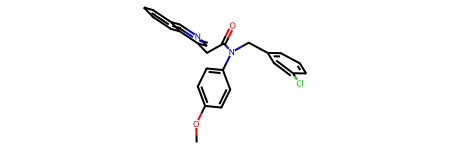

In [15]:
top_mol_test_1

In [ ]:
blah = read_sdf("/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_1_MERS-CoV-Mpro.sdf")

In [22]:
top_mols = []
top_mol_cnns = []
for row in df_sdfs.iter_rows(named=True):
    logger.debug(f"Processing {row["ligand_id"]}...")
    top_mol = get_top_cnnscore_for_sdf(row["sdf"])
    top_mol_cnn = float(top_mol.GetProp("CNNscore"))
    top_mols.append(top_mol)
    top_mol_cnns.append(top_mol_cnn)

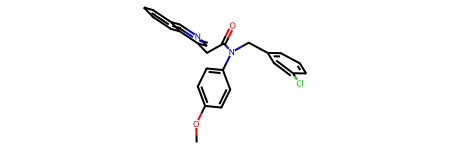

In [23]:
top_mols[1]

In [25]:
top_mol_cnns[1]

0.5794819593

In [ ]:
with Chem.SDWriter("tops.sdf", "a") as w:
    for i in tops:
        w.write(mol=i)

In [26]:
df_sdfs = df_sdfs.with_columns([pl.Series(name="best_mol", values=top_mols), pl.Series(name="cnn_score", values=top_mol_cnns)])

In [32]:
df_sdfs_mers = df_sdfs.filter(pl.col("protein_label").eq("MERS-CoV-Mpro"))
df_sdfs_sars = df_sdfs.filter(pl.col("protein_label").eq("SARS-CoV-2-Mpro"))

In [33]:
df_sdfs_mers.head()

sdf,test_or_train,ligand_id,protein_label,best_mol,cnn_score
object,str,i32,str,object,f64
/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_0_MERS-CoV-Mpro.sdf,"""test""",0,"""MERS-CoV-Mpro""",<rdkit.Chem.rdchem.Mol object at 0x745ce338ab20>,0.337507
/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_1_MERS-CoV-Mpro.sdf,"""test""",1,"""MERS-CoV-Mpro""",<rdkit.Chem.rdchem.Mol object at 0x745ce338ace0>,0.579482
/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_3_MERS-CoV-Mpro.sdf,"""test""",3,"""MERS-CoV-Mpro""",<rdkit.Chem.rdchem.Mol object at 0x745ce338aab0>,0.693848
/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_4_MERS-CoV-Mpro.sdf,"""test""",4,"""MERS-CoV-Mpro""",<rdkit.Chem.rdchem.Mol object at 0x745ce338adc0>,0.285249
/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_9_MERS-CoV-Mpro.sdf,"""test""",9,"""MERS-CoV-Mpro""",<rdkit.Chem.rdchem.Mol object at 0x745ce338a960>,0.555196


In [34]:
df_sdfs_sars.head()

sdf,test_or_train,ligand_id,protein_label,best_mol,cnn_score
object,str,i32,str,object,f64
/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_2_SARS-CoV-2-Mpro.sdf,"""test""",2,"""SARS-CoV-2-Mpro""",<rdkit.Chem.rdchem.Mol object at 0x745ce338ac70>,0.679494
/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_5_SARS-CoV-2-Mpro.sdf,"""test""",5,"""SARS-CoV-2-Mpro""",<rdkit.Chem.rdchem.Mol object at 0x745ce338ad50>,0.388301
/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_6_SARS-CoV-2-Mpro.sdf,"""test""",6,"""SARS-CoV-2-Mpro""",<rdkit.Chem.rdchem.Mol object at 0x745ce338a9d0>,0.660752
/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_7_SARS-CoV-2-Mpro.sdf,"""test""",7,"""SARS-CoV-2-Mpro""",<rdkit.Chem.rdchem.Mol object at 0x745ce338aea0>,0.56079
/home/cbrown/workspace/polaris-asap-poses/data/gnina-out/docked_test_8_SARS-CoV-2-Mpro.sdf,"""test""",8,"""SARS-CoV-2-Mpro""",<rdkit.Chem.rdchem.Mol object at 0x745ce338a810>,0.52533


In [39]:
with Chem.SDWriter("top_mers.sdf") as w:
    for i in df_sdfs_mers["best_mol"].to_list():
        w.write(mol=i)

In [40]:
with Chem.SDWriter("top_sars.sdf") as w:
    for i in df_sdfs_sars["best_mol"].to_list():
        w.write(mol=i)